# **1. Perkenalan Dataset**


Dataset ini adalah Churn Modelling yang berisi data profil nasabah suatu bank. Tujuannya adalah untuk memprediksi apakah nasabah tersebut akan keluar/berhenti berlangganan (Exited = 1) atau tetap bertahan (Exited = 0).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Library siap digunakan!")

Library siap digunakan!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
raw_data_path = 'Churn_Modelling.csv'
df = pd.read_csv(raw_data_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Struktur Dataset Churn Modelling ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

=== Statistik Deskriptif ===
         RowNumber    C

C:\Users\nabil\AppData\Local\Temp\ipykernel_17840\1745372787.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='Set1')


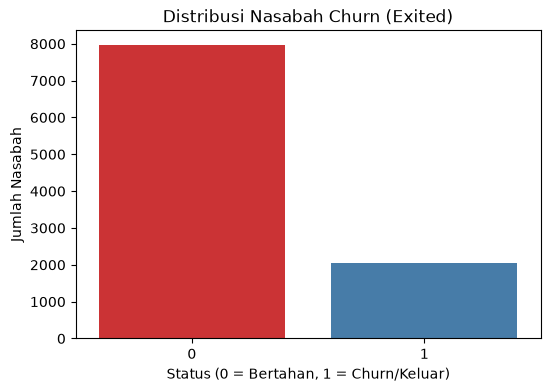

In [3]:
print("=== Struktur Dataset Churn Modelling ===")
df.info()

print("\n=== Statistik Deskriptif ===")
print(df.describe())

print("\n=== Pengecekan Data Kosong ===")
print(df.isnull().sum())
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', palette='Set1')
plt.title('Distribusi Nasabah Churn (Exited)')
plt.xlabel('Status (0 = Bertahan, 1 = Churn/Keluar)')
plt.ylabel('Jumlah Nasabah')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
df_clean = df.copy()

kolom_tidak_penting = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df_clean.drop(columns=kolom_tidak_penting, errors='ignore')

for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

le_geo = LabelEncoder()
le_gender = LabelEncoder()

if 'Geography' in df_clean.columns:
    df_clean['Geography'] = le_geo.fit_transform(df_clean['Geography'])
if 'Gender' in df_clean.columns:
    df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

scaler = StandardScaler()
kolom_numerik = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df_clean[kolom_numerik] = scaler.fit_transform(df_clean[kolom_numerik])

os.makedirs('preprocessing', exist_ok=True)
clean_data_path = 'preprocessing/Churn_Modelling_clean.csv'
df_clean.to_csv(clean_data_path, index=False)

print("=== Hasil Akhir Preprocessing Churn Modelling ===")
print(df_clean.head())
print(f"\nFile bersih berhasil disimpan di: {clean_data_path}")

=== Hasil Akhir Preprocessing Churn Modelling ===
   CreditScore  Geography  Gender       Age    Tenure   Balance  \
0    -0.326221          0       0  0.293517 -1.041760 -1.225848   
1    -0.440036          2       0  0.198164 -1.387538  0.117350   
2    -1.536794          0       0  0.293517  1.032908  1.333053   
3     0.501521          0       0  0.007457 -1.387538 -1.225848   
4     2.063884          2       0  0.388871 -1.041760  0.785728   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0      -0.911583          1               1         0.021886       1  
1      -0.911583          0               1         0.216534       0  
2       2.527057          1               0         0.240687       1  
3       0.807737          0               0        -0.108918       0  
4      -0.911583          1               1        -0.365276       0  

File bersih berhasil disimpan di: preprocessing/Churn_Modelling_clean.csv
